# EDA

# Modelo 1

## 1. Importación de librerías

In [5]:
import os
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread
import sys
sys.path.insert(0, str(pathlib.Path().resolve().parent))
from src.CNN import procesar_lote_videos_split, vaciar_contenido

## 2. Rutas

In [2]:
ROOT       = pathlib.Path().resolve().parent
train_path = str(ROOT / 'data' / 'processed' / 'train')
test_path  = str(ROOT / 'data' / 'processed' / 'test')
print(train_path)

C:\Users\kenda\Downloads\SmartCityIA-main (1)\SmartCityIA-main\data\processed\train


## 3. Fuentes de datos — conteo de videos por clase

In [6]:
import os
import pathlib
ROOT = pathlib.Path().resolve().parent

clases_raw = {
    'Normal':     ROOT / 'data' / 'raw' / 'Videos' / 'Normal-Videos-Part-1',
    'Pelea':      ROOT / 'data' / 'raw' / 'Videos' / 'Fighting',
    'Asaltos':    ROOT / 'data' / 'raw' / 'Videos' / 'Assault',
    'Arson':      ROOT / 'data' / 'raw' / 'Videos' / 'Arson',
    'Vandalismo': ROOT / 'data' / 'raw' / 'Videos' / 'Vandalism',
    'Stealing':   ROOT / 'data' / 'raw' / 'Videos' / 'Stealing',
}
for nombre, ruta in clases_raw.items():
    total = len(os.listdir(ruta)) if ruta.exists() else 'N/A'
    print(f'{nombre}: {total} videos')

Normal: 150 videos
Pelea: 30 videos
Asaltos: 50 videos
Arson: 50 videos
Vandalismo: 48 videos
Stealing: 44 videos


## 4. Extracción de fotogramas

In [ ]:
vaciar_contenido()

### 4.1 Normal

In [ ]:
procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Normal-Videos-Part-1'),
    carpeta_base_destino='Normal', limite_videos=150, cada_n_frames=90, umbral=1.2, max_fotos_video=5000)

procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Fighting'),
    carpeta_base_destino='Pelea', limite_videos=30, cada_n_frames=10, umbral=1.0, max_fotos_video=5000)### 4.2 Pelea

In [ ]:
procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Fighting'),
    carpeta_base_destino='Pelea', limite_videos=30, cada_n_frames=10, umbral=1.0, max_fotos_video=5000)

### 4.3 Vandalismo|

In [ ]:
procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Vandalism'),
    carpeta_base_destino='Vandalismo', limite_videos=48, cada_n_frames=10, umbral=1.0, max_fotos_video=5000)

### 4.4 Arson → Vandalismo

In [ ]:
procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Arson'),
    carpeta_base_destino='Vandalismo', limite_videos=50, cada_n_frames=10, umbral=0.6, max_fotos_video=5000)

### 4.5 Asaltos

In [ ]:
procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Assault'),
    carpeta_base_destino='Asaltos', limite_videos=50, cada_n_frames=10, umbral=0.5, max_fotos_video=5000)

### 4.6 Stealing → Asaltos

In [ ]:
procesar_lote_videos_split(
    ruta_carpeta=str(ROOT / 'data' / 'raw' / 'Videos' / 'Stealing'),
    carpeta_base_destino='Asaltos', limite_videos=44, cada_n_frames=5, umbral=1.0, max_fotos_video=5000)

## 5. Preprocesado — cantidad de imágenes por clase

In [7]:
for clase in ['Normal', 'Asaltos', 'Pelea', 'Vandalismo']:
    n = len(os.listdir(train_path + '\\' + clase))
    print(f'{clase}: {n} imágenes en train')

Normal: 536 imágenes en train
Asaltos: 519 imágenes en train
Pelea: 680 imágenes en train
Vandalismo: 512 imágenes en train


## 6. Visualización de imágenes de muestra

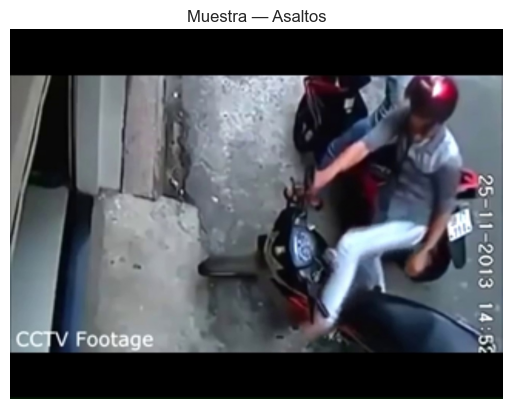

Shape: (720, 960, 3)


In [8]:
ruta_Asalto = train_path + '/Asaltos/' + os.listdir(train_path + '/Asaltos')[0]
imagen_Asalto = imread(ruta_Asalto)
plt.imshow(imagen_Asalto)
plt.title('Muestra — Asaltos')
plt.axis('off')
plt.show()
print('Shape:', imagen_Asalto.shape)

## 7. Graficos


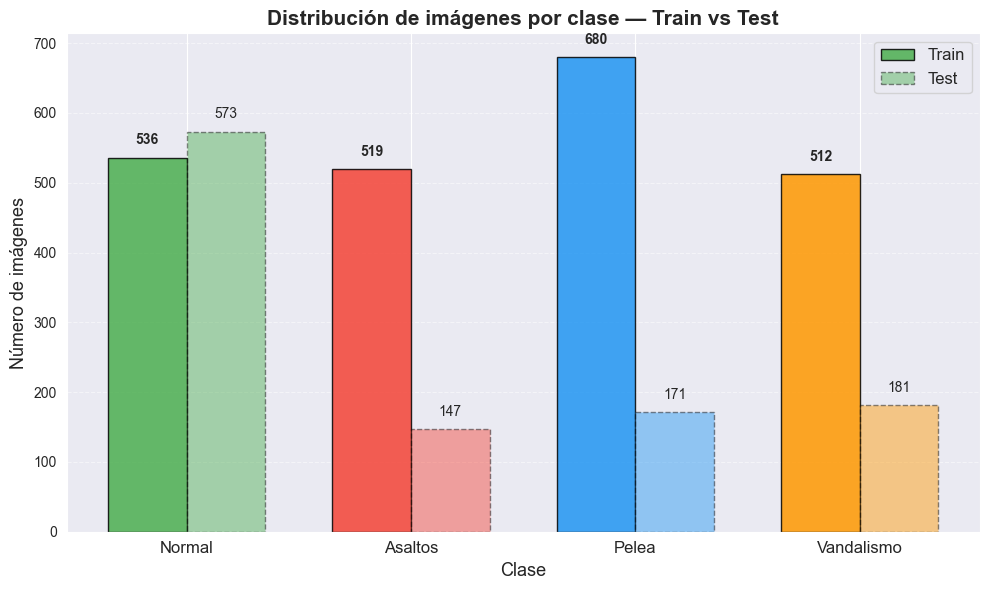

In [11]:
import os, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

clases = ['Normal', 'Asaltos', 'Pelea', 'Vandalismo']
colores = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']

conteos_train = []
conteos_test  = []

for clase in clases:
    t_path = os.path.join(train_path, clase)
    ts_path = os.path.join(test_path, clase)
    conteos_train.append(len(os.listdir(t_path)) if os.path.exists(t_path) else 0)
    conteos_test.append(len(os.listdir(ts_path))  if os.path.exists(ts_path) else 0)

x = np.arange(len(clases))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - ancho/2, conteos_train, ancho, label='Train', color=colores, alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + ancho/2, conteos_test,  ancho, label='Test',  color=colores, alpha=0.45, edgecolor='black', linestyle='--')

ax.set_xlabel('Clase', fontsize=13)
ax.set_ylabel('Número de imágenes', fontsize=13)
ax.set_title('Distribución de imágenes por clase — Train vs Test', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


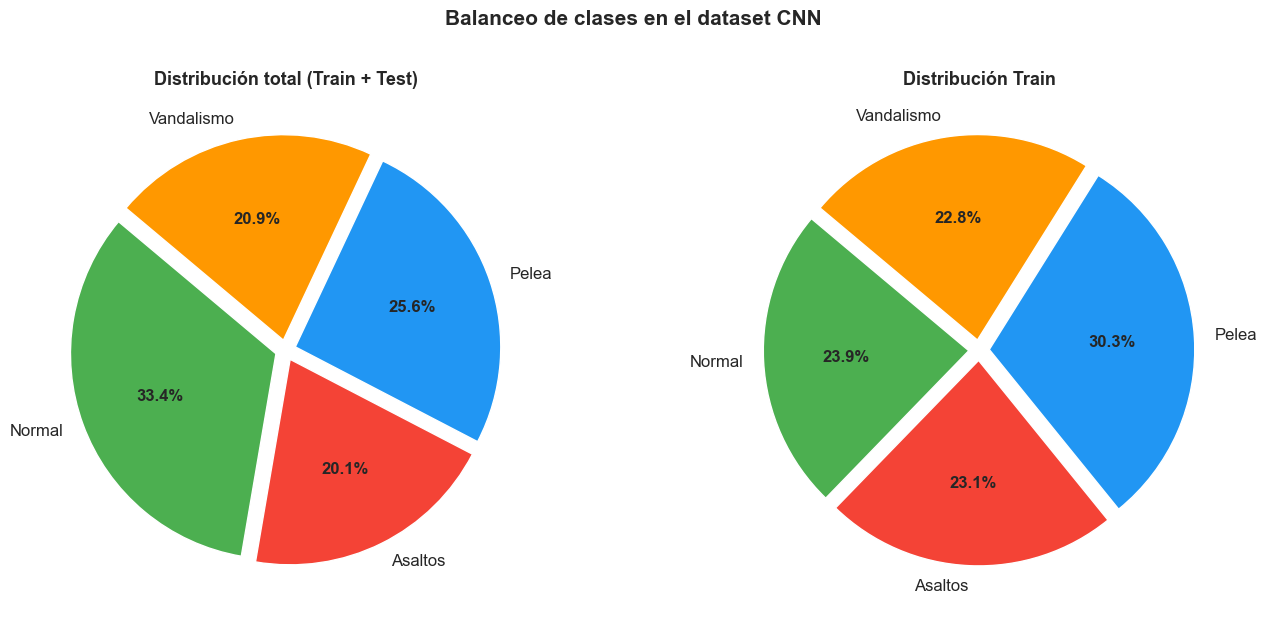

In [12]:
clases = ['Normal', 'Asaltos', 'Pelea', 'Vandalismo']
colores = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']

total = [conteos_train[i] + conteos_test[i] for i in range(len(clases))]
explode = [0.05] * len(clases)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Total ---
wedges, texts, autotexts = axes[0].pie(
    total, labels=clases, autopct='%1.1f%%',
    colors=colores, explode=explode, startangle=140,
    textprops={'fontsize': 12})
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Distribución total (Train + Test)', fontsize=13, fontweight='bold')

# --- Solo Train ---
wedges2, texts2, autotexts2 = axes[1].pie(
    conteos_train, labels=clases, autopct='%1.1f%%',
    colors=colores, explode=explode, startangle=140,
    textprops={'fontsize': 12})
for at in autotexts2:
    at.set_fontweight('bold')
axes[1].set_title('Distribución Train', fontsize=13, fontweight='bold')

plt.suptitle('Balanceo de clases en el dataset CNN', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


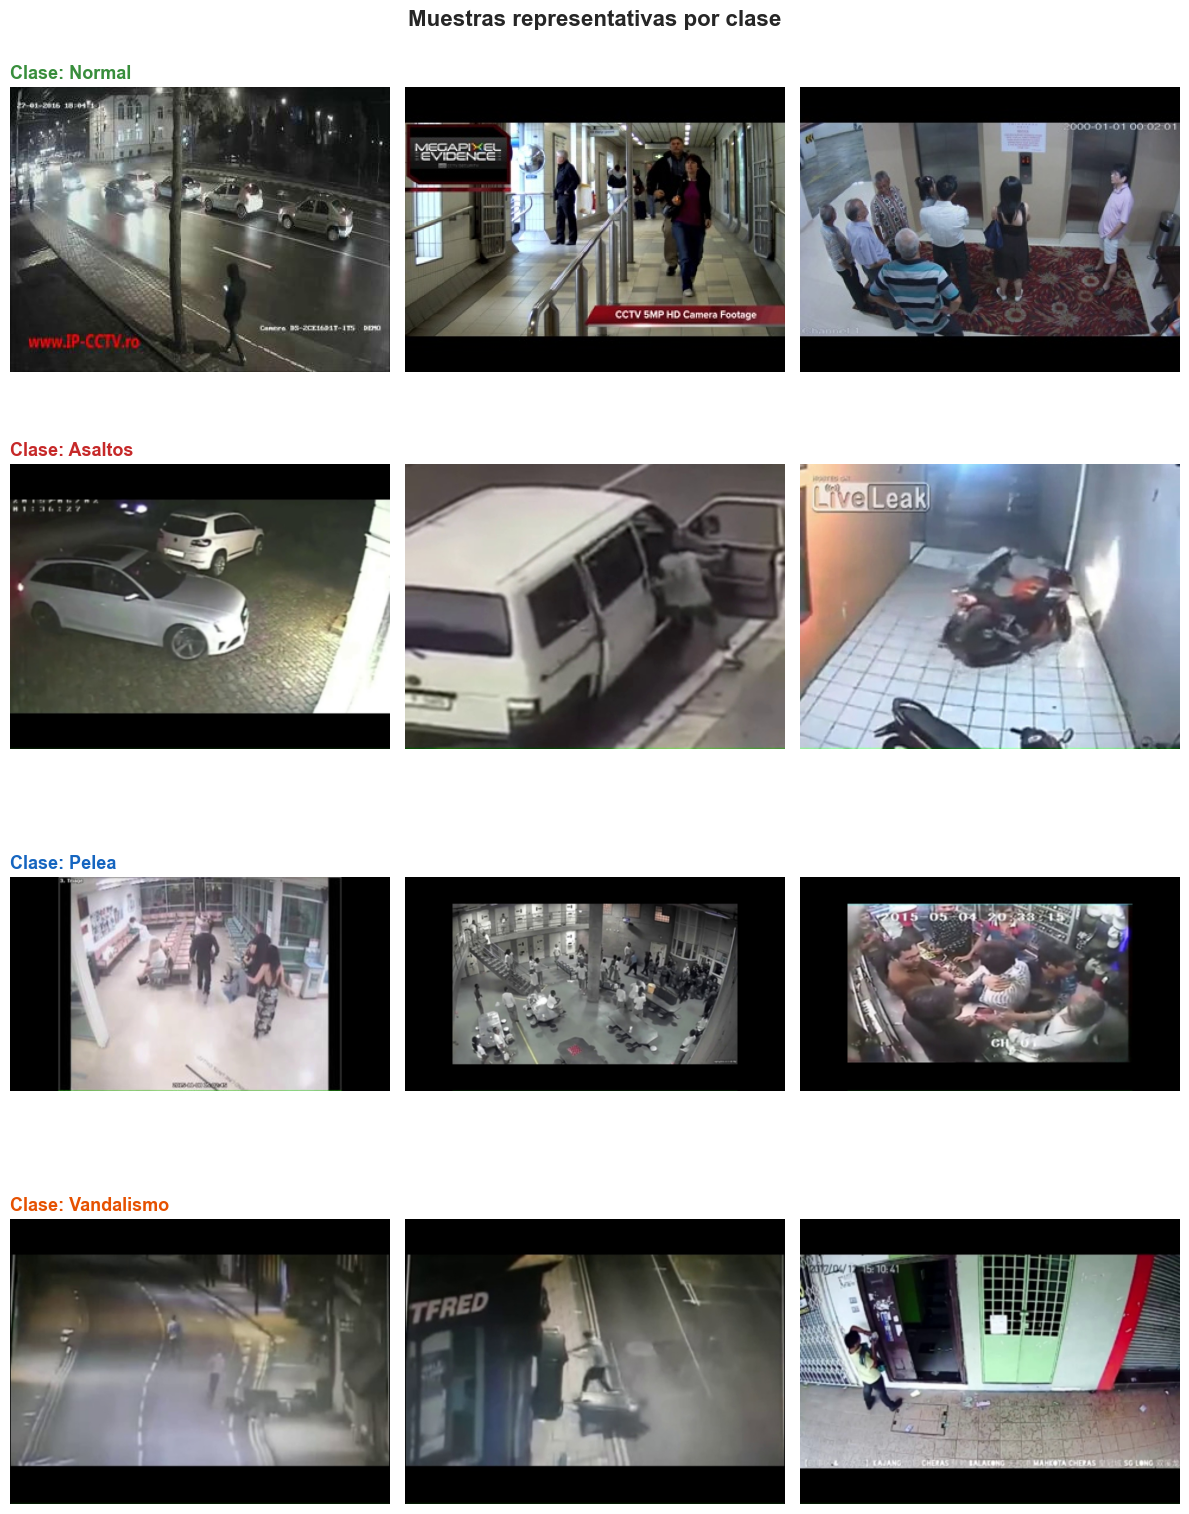

In [13]:
from matplotlib.image import imread
import random

clases = ['Normal', 'Asaltos', 'Pelea', 'Vandalismo']
colores_titulo = ['#388E3C', '#C62828', '#1565C0', '#E65100']
n_muestras = 3

fig, axes = plt.subplots(len(clases), n_muestras, figsize=(12, 4 * len(clases)))

for fila, (clase, color) in enumerate(zip(clases, colores_titulo)):
    ruta_clase = os.path.join(train_path, clase)
    archivos   = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    muestra    = random.sample(archivos, min(n_muestras, len(archivos)))

    for col, archivo in enumerate(muestra):
        img = imread(os.path.join(ruta_clase, archivo))
        axes[fila][col].imshow(img)
        axes[fila][col].axis('off')
        if col == 0:
            axes[fila][col].set_title(f'Clase: {clase}', fontsize=13,
                                       fontweight='bold', color=color, loc='left')

plt.suptitle('Muestras representativas por clase', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


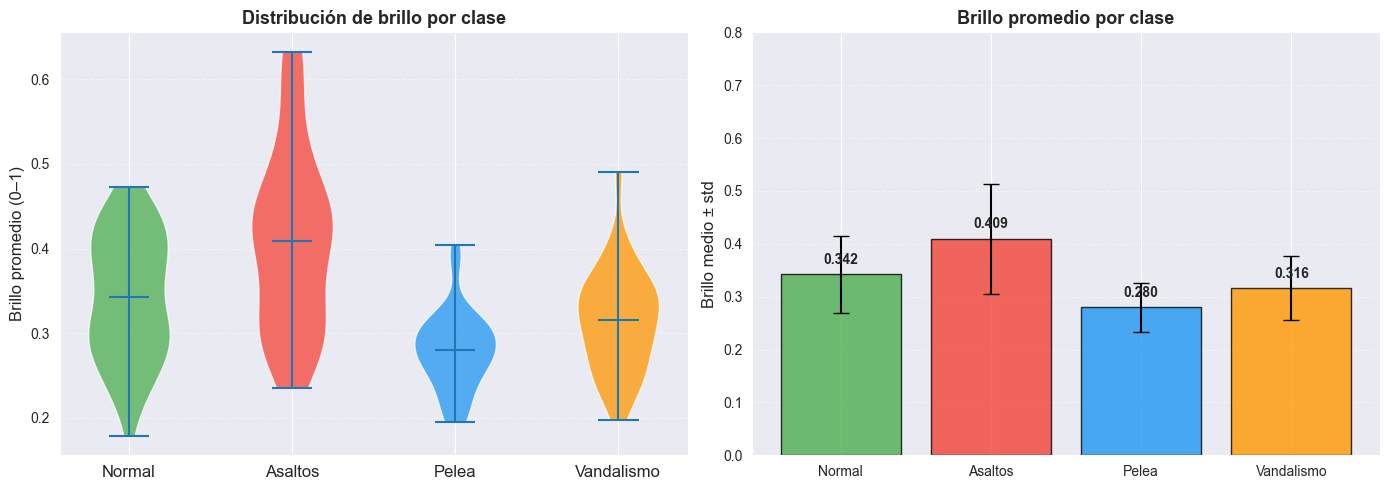

In [15]:
import random
import numpy as np

clases  = ['Normal', 'Asaltos', 'Pelea', 'Vandalismo']
colores = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']
n_sample = 60

brillo_por_clase = {}

for clase in clases:
    ruta_clase = os.path.join(train_path, clase)
    archivos   = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    muestra    = random.sample(archivos, min(n_sample, len(archivos)))
    brillos = []
    for archivo in muestra:
        img = imread(os.path.join(ruta_clase, archivo))
        if img.max() > 1:
            img = img / 255.0
        brillos.append(img.mean())
    brillo_por_clase[clase] = brillos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
parts = axes[0].violinplot(
    [brillo_por_clase[c] for c in clases],
    showmeans=True, showmedians=False)

for i, (pc, color) in enumerate(zip(parts['bodies'], colores)):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)

axes[0].set_xticks(range(1, len(clases)+1))
axes[0].set_xticklabels(clases, fontsize=12)
axes[0].set_ylabel('Brillo promedio (0–1)', fontsize=12)
axes[0].set_title('Distribución de brillo por clase', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Barras de media ± std
medias = [np.mean(brillo_por_clase[c]) for c in clases]
stds   = [np.std(brillo_por_clase[c])  for c in clases]

bars = axes[1].bar(clases, medias, yerr=stds, capsize=6,
                   color=colores, alpha=0.80, edgecolor='black')
axes[1].set_ylabel('Brillo medio ± std', fontsize=12)
axes[1].set_title('Brillo promedio por clase', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 0.8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar, m in zip(bars, medias):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# Modelo 2


## Importación de librerías

In [16]:
import sys
import pathlib
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga de Datos

In [17]:

# 1. Definir la ruta base donde se encuentra este notebook
# .resolve().parent apunta a la carpeta 'notebooks'
base_path = pathlib.Path().resolve().parent

# 2. Construir la ruta hacia el CSV usando los nombres de las carpetas
# Esto une automáticamente las carpetas con / o \ según el sistema operativo
data_path = base_path / "data" / "raw" / "Reportes" / "Estadisticas OIJ.csv"

# 3. Cargar el archivo
try:
    df = pd.read_csv(data_path)
    print("Archivo cargado exitosamente desde:", data_path)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {data_path}")
    print("Verifica que la carpeta 'data' esté al mismo nivel que la carpeta 'notebooks'.")

df.head()

Archivo cargado exitosamente desde: C:\Users\kenda\Downloads\SmartCityIA-main (1)\SmartCityIA-main\data\raw\Reportes\Estadisticas OIJ.csv


,Delito,SubDelito,Fecha,Rango Horario,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton
0,ASALTO,ARMA BLANCA,01/02/2022,12:00:00 - 14:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ASERRI
1,ASALTO,ARMA BLANCA,03/02/2022,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA
2,ASALTO,ARMA BLANCA,04/02/2022,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,06/02/2022,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,08/02/2022,00:00:00 - 02:59:59,PERSONA,TURISTA/EXTRANJERO [PERSONA],Mayor de edad,HOMBRE,RUSIA,PUNTARENAS,GARABITO


## Limpieza de datos

In [18]:
df.columns = df.columns.str.strip()

df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors='coerce')

cols_texto = ["Delito", "SubDelito", "Provincia", "Canton", "Sexo"]
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()


cols_texto = ["Delito", "SubDelito", "Provincia", "Canton", "Sexo", "Edad"]

for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()

# 2. ELIMINA o comenta esta línea, ya que no son números:
# df["Edad"] = pd.to_numeric(df["Edad"], errors='coerce')

df = df.dropna(subset=["Fecha", "Delito"])

print("\nDatos después de limpieza:")
df.info()
df = df.map(lambda x: str(x).strip().upper() if isinstance(x, str) else x)
df = df[~df.isin(["DESCONOCIDO"]).any(axis=1)]

print("Nuevo tamaño del dataset:", df.shape)


Datos después de limpieza:
<class 'pandas.DataFrame'>
RangeIndex: 173432 entries, 0 to 173431
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Delito         173432 non-null  str           
 1   SubDelito      173432 non-null  str           
 2   Fecha          173432 non-null  datetime64[us]
 3   Rango Horario  173432 non-null  str           
 4   Victima        173432 non-null  str           
 5   SubVictima     173432 non-null  str           
 6   Edad           173432 non-null  str           
 7   Sexo           173432 non-null  str           
 8   Nacionalidad   173432 non-null  str           
 9   Provincia      173432 non-null  str           
 10  Canton         173432 non-null  str           
dtypes: datetime64[us](1), str(10)
memory usage: 14.6 MB
Nuevo tamaño del dataset: (163432, 11)


## Analisis General

In [19]:
print("\nTop delitos:")
print(df["Delito"].value_counts().head(10))

print("\nTop provincias:")
print(df["Provincia"].value_counts())


Top delitos:
Delito
HURTO                54817
ASALTO               41005
ROBO                 31929
ROBO DE VEHICULO     18392
TACHA DE VEHICULO    14562
HOMICIDIO             2727
Name: count, dtype: int64

Top provincias:
Provincia
SAN JOSE      62260
ALAJUELA      26068
PUNTARENAS    19386
GUANACASTE    15708
LIMON         14424
HEREDIA       13592
CARTAGO       11994
Name: count, dtype: int64


## Delitos mas frecuentes

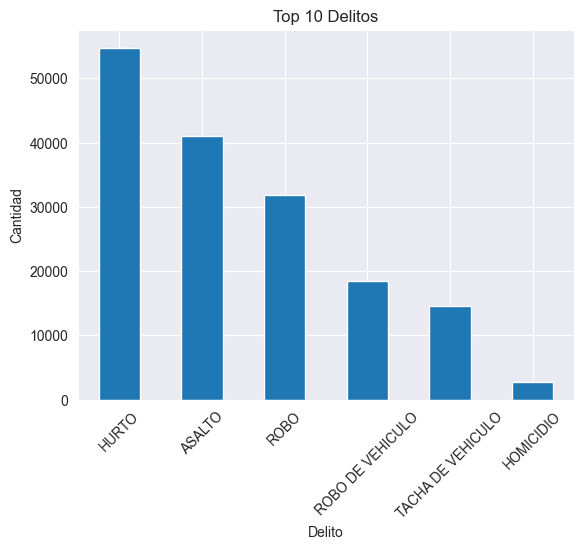

In [20]:
top_delitos = df["Delito"].value_counts().head(10)

plt.figure()
top_delitos.plot(kind='bar')
plt.title("Top 10 Delitos")
plt.xlabel("Delito")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

## Analisis por genero

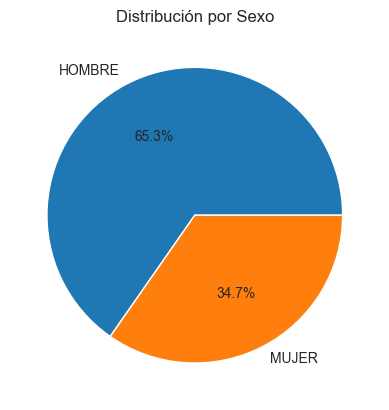

In [21]:
sexo_counts = df["Sexo"].value_counts()

plt.figure()
sexo_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribución por Sexo")
plt.ylabel("")
plt.show()

## Top Provincias

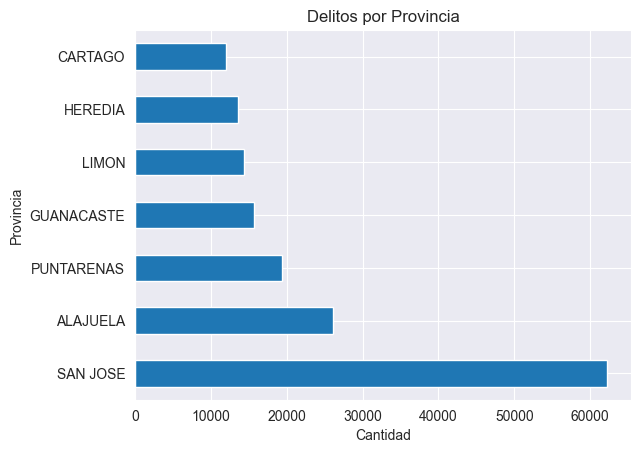

In [22]:
prov_counts = df["Provincia"].value_counts()

plt.figure()
prov_counts.plot(kind='barh')
plt.title("Delitos por Provincia")
plt.xlabel("Cantidad")
plt.show()

## Conclusiones

In [23]:
print("\n Conclusiones")

print("Delito más común:", df["Delito"].value_counts().idxmax())
print("Provincia con más delitos:", df["Provincia"].value_counts().idxmax())
print("Genero con más delitos:", df["Sexo"].value_counts().idxmax())


 Conclusiones
Delito más común: HURTO
Provincia con más delitos: SAN JOSE
Genero con más delitos: HOMBRE


## Guardar datos limpios

In [24]:
base_path = pathlib.Path().resolve().parent
save_path = base_path / "data" / "processed" / "delitos_limpios.csv"

save_path.parent.mkdir(parents=True, exist_ok=True)

# 3. Guardar el DataFrame
# index=False evita que se cree una columna extra con los números de fila
df.to_csv(save_path, index=False, encoding='utf-8')

print(f"Dataset guardado exitosamente en: {save_path}")
print(f"Finalizado con {df.shape[0]} registros y {df.shape[1]} columnas.")

Dataset guardado exitosamente en: C:\Users\kenda\Downloads\SmartCityIA-main (1)\SmartCityIA-main\data\processed\delitos_limpios.csv
Finalizado con 163432 registros y 11 columnas.
